# Step 8: Control-Split Sensitivity Analysis (Authoritative v4)

This notebook analyzes the completed **near-optimal control-split retuning** study for v4 using the canonical summary at `experiments/results/v4/control_split_sensitivity/sensitivity_summary_v4.json`. Step 8 should be read as a **sensitivity analysis**, not as proof that the main transfer story is invariant to alternate control partitions.


In [1]:

import json
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for base in candidates:
        if (base / 'data' / 'processed' / 'v4' / 'v4_protocol_manifest.json').exists():
            return base
    raise RuntimeError('Could not locate repository root from the current working directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

STEP_TAG = 'step8'
FIG_PDF = REPO_ROOT / 'report' / 'figures' / 'v4' / 'pdf' / STEP_TAG
FIG_PNG = REPO_ROOT / 'report' / 'figures' / 'v4' / 'png' / STEP_TAG
TABLE_DIR = REPO_ROOT / 'report' / 'tables' / 'v4'
for directory in (FIG_PDF, FIG_PNG, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 180,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

IEEE_ONE_COL = 3.5
IEEE_TWO_COL = 7.16
COND_ORDER = ['pd', 'hd', 'als']
COND_LABEL = {'pd': 'PD', 'hd': 'HD', 'als': 'ALS'}
CLF_ORDER = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABEL = {'rf': 'RF', 'knn': 'KNN', 'svm': 'SVM', 'dt': 'DT', 'qda': 'QDA', 'xgb': 'XGBoost', 'lgbm': 'LightGBM'}
DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABEL = {
    'pd_to_hd': 'PD→HD',
    'hd_to_pd': 'HD→PD',
    'pd_to_als': 'PD→ALS',
    'als_to_pd': 'ALS→PD',
    'hd_to_als': 'HD→ALS',
    'als_to_hd': 'ALS→HD',
}
PARTITION_COLOR = {1: '#4C78A8', 2: '#F58518', 3: '#54A24B'}
MAIN_COLOR = '#2F2F2F'

SUMMARY_PATH = REPO_ROOT / 'experiments' / 'results' / 'v4' / 'control_split_sensitivity' / 'sensitivity_summary_v4.json'
if not SUMMARY_PATH.exists():
    step8_payload = None
    RUN_ROOT = None
else:
    step8_payload = json.loads(SUMMARY_PATH.read_text())
    RUN_ROOT = (
        REPO_ROOT / 'experiments' / 'results' / 'v4' / 'control_split_sensitivity_runs' /
        step8_payload['downstream_execution_id'] / step8_payload['candidate_family']
    )


def savefig_stem(fig: plt.Figure, stem: str) -> None:
    pdf_path = FIG_PDF / f'{stem}.pdf'
    png_path = FIG_PNG / f'{stem}.png'
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=300)
    print(f'Saved figure: {pdf_path.relative_to(REPO_ROOT)}')
    print(f'Saved figure: {png_path.relative_to(REPO_ROOT)}')


def save_table_csv(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    path = TABLE_DIR / name
    df.to_csv(path, index=index)
    print(f'Saved table: {path.relative_to(REPO_ROOT)}')


def lighten_color(color, amount=0.82):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1.0 - rgb) * amount)


def render_table_figure(
    df: pd.DataFrame,
    stem: str,
    title: str,
    fig_width: float = IEEE_TWO_COL,
    fontsize: float = 7.5,
    wrap_headers: bool = False,
    col_width_weights: dict[str, float] | None = None,
    header_fontsize: float | None = None,
):
    header_labels = df.columns.tolist()
    if wrap_headers:
        header_labels = [
            label.replace('Overlap with main Control A', 'Overlap with\nmain Control A')
                 .replace('Independent candidate', 'Independent\ncandidate')
                 .replace('Sign agreement rate', 'Sign agreement\nrate')
                 .replace('Ordering rank correlation', 'Ordering rank\ncorrelation')
                 .replace('Age delta (years)', 'Age delta\n(years)')
                 .replace('Gait-speed delta (m/s)', 'Gait-speed delta\n(m/s)')
            for label in header_labels
        ]
    header_line_count = max(label.count('\n') + 1 for label in header_labels)
    header_fontsize = fontsize if header_fontsize is None else header_fontsize
    fig_height = max(2.25, 0.48 * len(df) + 0.56 + 0.28 * header_line_count)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_title(title, fontsize=10, pad=10)
    table_bbox = [0.01, 0.03, 0.98, 0.90]
    table = ax.table(
        cellText=df.astype(str).values.tolist(),
        colLabels=header_labels,
        cellLoc='center',
        colLoc='center',
        bbox=table_bbox,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1.04, 1.34)

    if col_width_weights is None:
        col_width_weights = {col: 1.0 for col in df.columns.tolist()}
    total_weight = sum(col_width_weights.get(col, 1.0) for col in df.columns.tolist())
    normalized_widths = [table_bbox[2] * col_width_weights.get(col, 1.0) / total_weight for col in df.columns.tolist()]

    base_header_height = None
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#D0D3D4')
        cell.set_linewidth(0.55)
        if col < len(normalized_widths):
            cell.set_width(normalized_widths[col])
        if row == 0:
            if base_header_height is None:
                base_header_height = cell.get_height()
            cell.set_facecolor('#EAF2F8')
            cell.set_text_props(weight='bold', color='#1B2631', va='center', fontsize=header_fontsize)
            cell.set_height(base_header_height * max(1.55, 1.55 * header_line_count))
            cell.PAD = 0.12
        else:
            cell.set_facecolor('#FFFFFF' if row % 2 else '#F8F9F9')
    savefig_stem(fig, stem)
    plt.show()


## Step 8 summary tables and run-derived detail

The first tables are the structural checkpoint for the completed sensitivity run. They verify that the local Step 8 summary exists, that the near-optimal candidate family is being read from the authoritative path, and that the partition-wise and direction-wise detail can be derived from the completed local run tree without redoing any training. That distinction matters because Step 8 is part of the final reporting layer, not a live recovery workflow anymore.


In [2]:

if step8_payload is None:
    pending_df = pd.DataFrame([
        {
            'status': 'pending',
            'path_checked': str(SUMMARY_PATH.relative_to(REPO_ROOT)),
            'candidate_family': 'near_optimal',
        }
    ])
    display(pending_df)
else:
    main_subject_delta = step8_payload['main_authoritative']['primary_direction_mean_matched_degradation_subject']
    main_within_best = step8_payload['main_authoritative']['within_best_subject_f1_by_source']
    partition_rows = []
    within_rows = []
    direction_rows = []
    leader_rows = []

    for part in step8_payload['partitions']:
        partition_index = int(part['partition_index'])
        partition_key = part['partition_key']
        partition_label = f"P{partition_index}{' (main)' if part['is_main_partition'] else ''}"
        within_payloads = {
            condition: json.loads((RUN_ROOT / partition_key / f'{condition}_results_v4_partition_{partition_index}.json').read_text())
            for condition in COND_ORDER
        }
        cross_payload = json.loads(
            (RUN_ROOT / partition_key / f'cross_condition_results_v4_partition_{partition_index}.json').read_text()
        )['cross_results']

        partition_rows.append({
            'Partition': partition_label,
            'Overlap with main Control A': int(part['overlap_with_main_control_a']),
            'Main partition': bool(part['is_main_partition']),
            'Role reversal of main': bool(part['is_role_reversal_of_main']),
            'Independent candidate': bool(part['independent_sensitivity_candidate']),
            'Sign agreement rate': part['stability_check']['n_directions_same_sign'] / len(DIRECTIONS),
            'Ordering rank correlation': float(part['stability_check']['ordering_rank_correlation']),
            'Age delta (years)': float(part['age_delta_years']),
            'Gait-speed delta (m/s)': float(part['gait_speed_delta_m_per_s']),
        })

        for condition in COND_ORDER:
            best_within = max(
                float(entry['subject_primary_f1_macro'])
                for entry in within_payloads[condition]['classifiers'].values()
            )
            within_rows.append({
                'partition_index': partition_index,
                'partition_label': partition_label,
                'condition': condition,
                'condition_label': COND_LABEL[condition],
                'best_subject_f1': best_within,
            })

        for direction in DIRECTIONS:
            direction_info = part['directions'][direction]
            clf_name, clf_entry = max(
                cross_payload[direction]['classifiers'].items(),
                key=lambda kv: float(kv[1]['subject_primary_f1_macro']),
            )
            direction_rows.append({
                'partition_index': partition_index,
                'partition_label': partition_label,
                'direction': direction,
                'direction_label': DIR_LABEL[direction],
                'mean_matched_degradation_subject': float(direction_info['primary_mean_matched_degradation_subject']),
                'median_matched_degradation_subject': float(direction_info['median_matched_degradation_subject']),
                'main_authoritative_subject_delta': float(main_subject_delta[direction]),
                'deviation_from_main': float(direction_info['primary_mean_matched_degradation_subject']) - float(main_subject_delta[direction]),
                'direction_sign': direction_info['direction_sign'],
                'best_classifier': clf_name,
                'best_classifier_label': CLF_LABEL[clf_name],
                'best_subject_f1': float(clf_entry['subject_primary_f1_macro']),
                'best_delta_subject': float(clf_entry['delta_f1_subject']),
            })
            leader_rows.append({
                'Partition': partition_label,
                'Direction': DIR_LABEL[direction],
                'Best classifier': CLF_LABEL[clf_name],
                'Best subject F1': float(clf_entry['subject_primary_f1_macro']),
                'Matched degradation (within - cross)': float(clf_entry['delta_f1_subject']),
            })

    partition_df = pd.DataFrame(partition_rows)
    within_df = pd.DataFrame(within_rows)
    direction_df = pd.DataFrame(direction_rows)
    leader_df = pd.DataFrame(leader_rows)

    save_table_csv(partition_df, 'step8_partition_overview_v4.csv')
    save_table_csv(within_df, 'step8_within_baselines_v4.csv')
    save_table_csv(direction_df, 'step8_direction_sensitivity_v4.csv')
    save_table_csv(leader_df, 'step8_best_transfer_leaders_v4.csv')

    display(
        partition_df.style.format({
            'Sign agreement rate': '{:.3f}',
            'Ordering rank correlation': '{:.3f}',
            'Age delta (years)': '{:.3f}',
            'Gait-speed delta (m/s)': '{:.4f}',
        }).set_caption('Partition-level summary for the completed near-optimal control-split retuning study')
    )


Saved table: report/tables/v4/step8_partition_overview_v4.csv
Saved table: report/tables/v4/step8_within_baselines_v4.csv
Saved table: report/tables/v4/step8_direction_sensitivity_v4.csv
Saved table: report/tables/v4/step8_best_transfer_leaders_v4.csv


,Partition,Overlap with main Control A,Main partition,Role reversal of main,Independent candidate,Sign agreement rate,Ordering rank correlation,Age delta (years),Gait-speed delta (m/s)
0,P1 (main),8,True,False,False,1.000,1.000,0.125,0.0037
1,P2,6,False,False,True,1.000,0.543,0.125,0.0037
2,P3,4,False,False,True,0.333,0.486,0.125,0.0037


## Partition overview table

The partition overview table is where the control-split story becomes concrete. **P1** is the main authoritative partition. **P2** is the nearest alternative and remains broadly concordant with the main sign pattern. **P3** is the strongest sensitivity stressor and should be treated as a genuine challenge to blanket stability claims. The table therefore supports a narrow but important manuscript claim: alternate near-optimal control partitions can preserve some conclusions while materially weakening others.


Saved figure: report/figures/v4/pdf/step8/step8_partition_overview_table.pdf
Saved figure: report/figures/v4/png/step8/step8_partition_overview_table.png


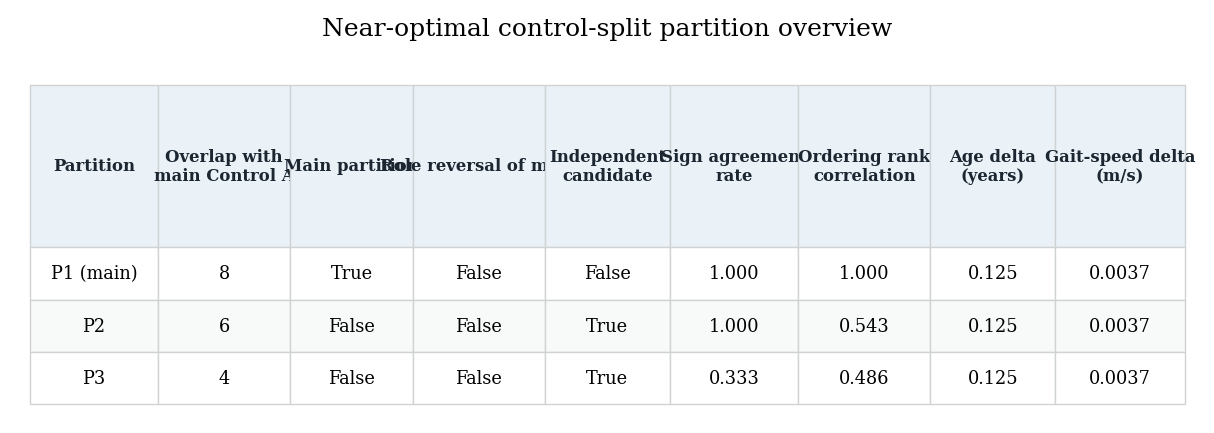

In [3]:

if step8_payload is not None:
    partition_view = partition_df.copy()
    partition_view['Sign agreement rate'] = partition_view['Sign agreement rate'].map(lambda x: f'{x:.3f}')
    partition_view['Ordering rank correlation'] = partition_view['Ordering rank correlation'].map(lambda x: f'{x:.3f}')
    partition_view['Age delta (years)'] = partition_view['Age delta (years)'].map(lambda x: f'{x:.3f}')
    partition_view['Gait-speed delta (m/s)'] = partition_view['Gait-speed delta (m/s)'].map(lambda x: f'{x:.4f}')
    render_table_figure(
        partition_view,
        'step8_partition_overview_table',
        'Near-optimal control-split partition overview',
        fig_width=IEEE_TWO_COL * 1.18,
        fontsize=7.1,
        wrap_headers=True,
        header_fontsize=6.6,
        col_width_weights={
            'Partition': 1.15,
            'Overlap with main Control A': 1.18,
            'Main partition': 1.10,
            'Role reversal of main': 1.18,
            'Independent candidate': 1.12,
            'Sign agreement rate': 1.15,
            'Ordering rank correlation': 1.18,
            'Age delta (years)': 1.12,
            'Gait-speed delta (m/s)': 1.16,
        },
    )


## Sign-stability matrix

This is the single most important Step 8 figure because it answers the yes-or-no version of the sensitivity question. The authoritative answer is mixed: **partition 2 preserves the direction-level matched-degradation signs**, whereas **partition 3 reverses four of six signs**. The specific reversals occur in **PD→HD**, **HD→PD**, **PD→ALS**, and **HD→ALS**. That is why Step 8 qualifies the main transfer conclusions rather than proving invariance.


Saved figure: report/figures/v4/pdf/step8/step8_sign_stability_matrix.pdf
Saved figure: report/figures/v4/png/step8/step8_sign_stability_matrix.png


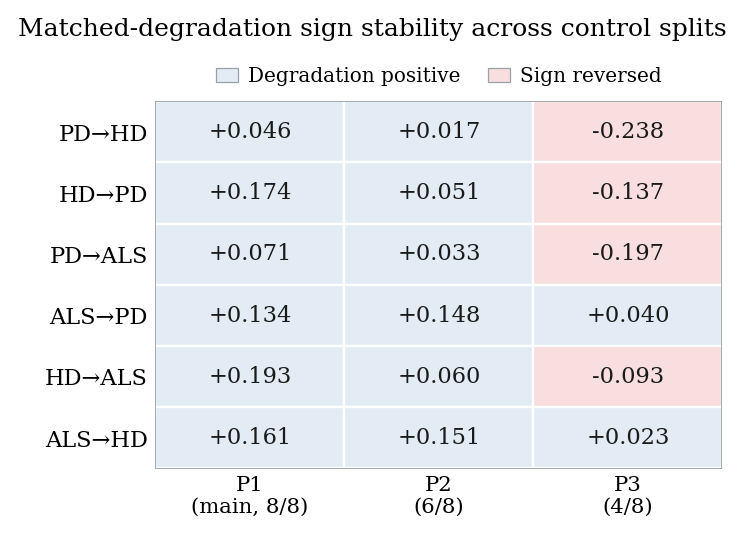

In [4]:
if step8_payload is not None:
    from matplotlib.patches import Patch, Rectangle

    # ── Manuscript figure: sign stability across control partitions ──────────
    # P1 is the main partition, so a separate "Main" column repeats P1 exactly.
    # The duplicate is dropped and the identity asserted instead, which also
    # matches the caption's description of three partitions.
    partition_columns = []
    for part in step8_payload['partitions']:
        index = int(part['partition_index'])
        overlap = int(part['overlap_with_main_control_a'])
        partition_columns.append({
            'index': index,
            'label': f"P{index}\n(main, {overlap}/8)" if part['is_main_partition'] else f"P{index}\n({overlap}/8)",
            'key': f"P{index}{' (main)' if part['is_main_partition'] else ''}",
        })

    sign_matrix = np.zeros((len(DIRECTIONS), len(partition_columns)), dtype=int)
    value_matrix = np.zeros((len(DIRECTIONS), len(partition_columns)), dtype=float)
    for row_idx, direction in enumerate(DIRECTIONS):
        for col_idx, column in enumerate(partition_columns):
            subset = direction_df[(direction_df['partition_label'] == column['key'])
                                  & (direction_df['direction'] == direction)].iloc[0]
            value_matrix[row_idx, col_idx] = float(subset['mean_matched_degradation_subject'])
            sign_matrix[row_idx, col_idx] = 1 if subset['direction_sign'] == '+' else 0
        main_column = next(c for c in partition_columns if '(main)' in c['key'])
        main_index = partition_columns.index(main_column)
        assert abs(value_matrix[row_idx, main_index] - float(main_subject_delta[direction])) < 1e-9, (
            f'the main partition column no longer reproduces the main authoritative estimate for {direction}'
        )

    # Blue against red rather than green against red: the sign contrast has to
    # survive the most common form of colour vision deficiency.
    POSITIVE_FILL, NEGATIVE_FILL = '#E3ECF5', '#F8DEDE'

    SIGN_FIG_W = IEEE_TWO_COL * 0.56
    SIGN_LEFT, SIGN_RIGHT = 0.80, 0.06
    SIGN_PLOT_W = SIGN_FIG_W - SIGN_LEFT - SIGN_RIGHT
    SIGN_ROW_H = 0.34
    SIGN_PLOT_H = SIGN_ROW_H * len(DIRECTIONS)
    SIGN_TOP, SIGN_TITLE_H, SIGN_LEGEND_H = 0.06, 0.28, 0.26
    SIGN_HEADER_H, SIGN_BOTTOM = 0.42, 0.06
    SIGN_FIG_H = (SIGN_TOP + SIGN_TITLE_H + SIGN_LEGEND_H + SIGN_PLOT_H
                  + SIGN_HEADER_H + SIGN_BOTTOM)

    fig = plt.figure(figsize=(SIGN_FIG_W, SIGN_FIG_H))
    ax = fig.add_axes((
        SIGN_LEFT / SIGN_FIG_W,
        (SIGN_BOTTOM + SIGN_HEADER_H) / SIGN_FIG_H,
        SIGN_PLOT_W / SIGN_FIG_W,
        SIGN_PLOT_H / SIGN_FIG_H,
    ))
    ax.set_xlim(0, len(partition_columns))
    ax.set_ylim(len(DIRECTIONS), 0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for row in range(value_matrix.shape[0]):
        for col in range(value_matrix.shape[1]):
            fill = POSITIVE_FILL if sign_matrix[row, col] == 1 else NEGATIVE_FILL
            ax.add_patch(Rectangle((col, row), 1, 1, facecolor=fill, edgecolor='white',
                                   linewidth=0.9, zorder=2))
            ax.text(col + 0.5, row + 0.5, f'{value_matrix[row, col]:+.3f}', ha='center',
                    va='center', fontsize=9, color='#1A1A1A', zorder=3)
    ax.add_patch(Rectangle((0, 0), len(partition_columns), len(DIRECTIONS), facecolor='none',
                           edgecolor='#9AA0A6', linewidth=0.7, zorder=4))

    ax.set_xticks(np.arange(len(partition_columns)) + 0.5)
    ax.set_xticklabels([c['label'] for c in partition_columns], fontsize=8.5)
    ax.set_yticks(np.arange(len(DIRECTIONS)) + 0.5)
    ax.set_yticklabels([DIR_LABEL[d] for d in DIRECTIONS], fontsize=9)
    ax.tick_params(length=0, pad=3)

    ax.legend(handles=[
        Patch(facecolor=POSITIVE_FILL, edgecolor='#9AA0A6', linewidth=0.5, label='Degradation positive'),
        Patch(facecolor=NEGATIVE_FILL, edgecolor='#9AA0A6', linewidth=0.5, label='Sign reversed'),
    ], loc='lower center', bbox_to_anchor=(0.5, 1.015), ncol=2, frameon=False,
        fontsize=8, handlelength=1.1, handletextpad=0.5, columnspacing=1.4, borderpad=0.0)

    fig.text(0.5, (SIGN_FIG_H - SIGN_TOP - SIGN_TITLE_H / 2) / SIGN_FIG_H,
             'Matched-degradation sign stability across control splits',
             ha='center', va='center', fontsize=10)

    savefig_stem(fig, 'step8_sign_stability_matrix')
    PAPER_FIG, PAPER_STEM = fig, 'step8_sign_stability_matrix'
    PAPER_CHECKS = [('duplicate column', value_matrix.shape[1] == 3,
                     f'columns shown: {value_matrix.shape[1]} (P1, P2, P3; the repeated Main column is gone)')]
    plt.show()


## Direction-level degradation ranges

The range figure complements the sign matrix by showing *how much* each direction moves across partitions. This matters because a sign flip near zero is scientifically different from a large directional reversal, and the saved v4 Step 8 results contain both scale movement and sign movement. The range panel therefore helps distinguish directions that remain qualitatively stable from directions whose effect sizes move enough to change the interpretation.


Saved figure: report/figures/v4/pdf/step8/step8_direction_degradation_ranges.pdf
Saved figure: report/figures/v4/png/step8/step8_direction_degradation_ranges.png


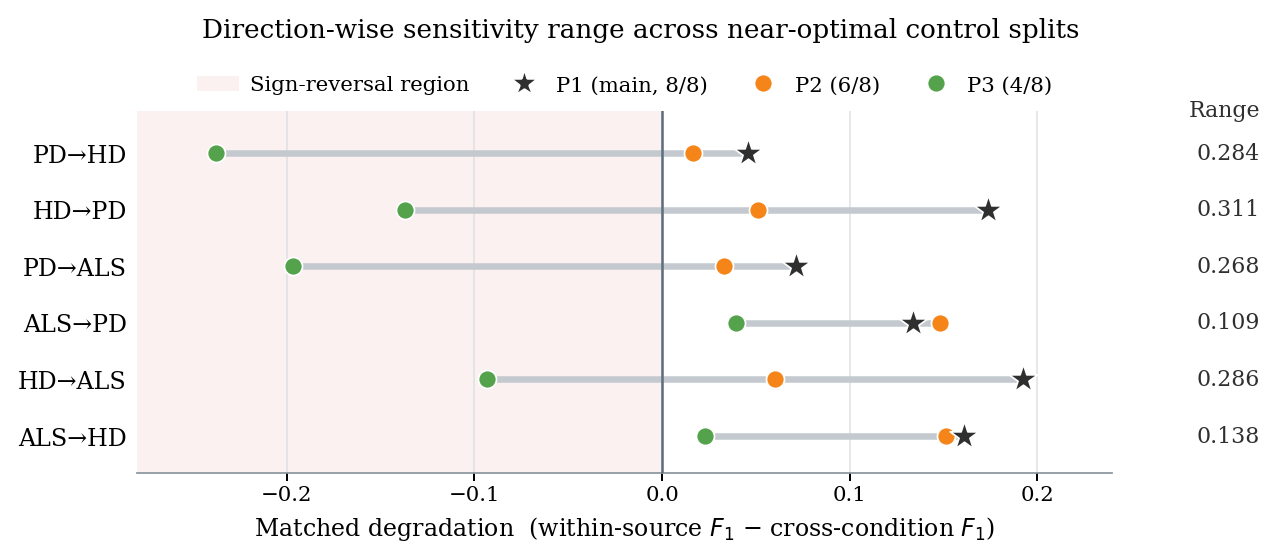

In [5]:
if step8_payload is not None:
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    # ── Panel geometry ───────────────────────────────────────────────────────
    # The plotting area, the right-hand range column and the legend are placed
    # explicitly so the float uses the full column width instead of reserving a
    # third of it for a legend parked outside the axes.
    FIG_W = IEEE_TWO_COL
    LEFT_MARGIN, RANGE_COL_W, RIGHT_PAD = 0.78, 0.92, 0.04
    PLOT_W = FIG_W - LEFT_MARGIN - RANGE_COL_W - RIGHT_PAD
    ROW_H = 0.335
    PLOT_H = ROW_H * len(DIRECTIONS)
    BOTTOM_MARGIN, XLABEL_H, XTICK_H = 0.06, 0.30, 0.22
    LEGEND_H, TITLE_H, TOP_MARGIN = 0.30, 0.30, 0.06
    FIG_H = (BOTTOM_MARGIN + XLABEL_H + XTICK_H + PLOT_H
             + LEGEND_H + TITLE_H + TOP_MARGIN)

    X_LIMITS = (-0.28, 0.24)
    REVERSAL_FILL = '#FBF1F1'
    RANGE_LINE = '#C3C9CE'

    # P1 is the main partition, so its value reproduces the main authoritative
    # estimate exactly. It is drawn once, as a star, rather than as a star and a
    # coincident dot that can never be seen. If the two ever diverge, collapsing
    # them would hide a real discrepancy, so verify the identity before plotting.
    p1_values = (
        direction_df[direction_df['partition_index'] == 1]
        .set_index('direction')['mean_matched_degradation_subject']
    )
    for direction in DIRECTIONS:
        assert abs(float(p1_values[direction]) - float(main_subject_delta[direction])) < 1e-9, (
            f'P1 no longer matches the main authoritative estimate for {direction}; '
            'the main estimate must be drawn as its own marker again'
        )

    PARTITION_STYLE = {
        1: {'label': 'P1 (main, 8/8)',
            'marker': '*', 'size': 145, 'color': MAIN_COLOR, 'zorder': 5},
        2: {'label': 'P2 (6/8)',
            'marker': 'o', 'size': 52, 'color': PARTITION_COLOR[2], 'zorder': 4},
        3: {'label': 'P3 (4/8)',
            'marker': 'o', 'size': 52, 'color': PARTITION_COLOR[3], 'zorder': 4},
    }

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    ax = fig.add_axes((
        LEFT_MARGIN / FIG_W,
        (BOTTOM_MARGIN + XLABEL_H + XTICK_H) / FIG_H,
        PLOT_W / FIG_W,
        PLOT_H / FIG_H,
    ))

    ax.axvspan(X_LIMITS[0], 0.0, color=REVERSAL_FILL, zorder=0)
    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#DDE1E4', linewidth=0.6)

    range_widths = []
    for row_idx, direction in enumerate(DIRECTIONS):
        frame = direction_df[direction_df['direction'] == direction].sort_values('partition_index')
        values = frame['mean_matched_degradation_subject'].to_numpy(dtype=float)
        ax.hlines(row_idx, values.min(), values.max(), color=RANGE_LINE, linewidth=2.6,
                  zorder=2, capstyle='round')
        for part_idx, value in zip(frame['partition_index'], values):
            style = PARTITION_STYLE[int(part_idx)]
            ax.scatter(value, row_idx, marker=style['marker'], s=style['size'],
                       color=style['color'], edgecolor='white', linewidth=0.7,
                       zorder=style['zorder'])
        range_widths.append(values.max() - values.min())

    ax.axvline(0.0, color='#5D6D7E', linewidth=1.0, zorder=3)

    ax.set_xlim(*X_LIMITS)
    ax.set_ylim(len(DIRECTIONS) - 0.35, -0.75)
    ax.set_yticks(np.arange(len(DIRECTIONS)))
    ax.set_yticklabels([DIR_LABEL[d] for d in DIRECTIONS], fontsize=9.5)
    ax.set_xticks([-0.2, -0.1, 0.0, 0.1, 0.2])
    ax.tick_params(axis='x', labelsize=8.5, length=3, pad=2)
    ax.tick_params(axis='y', length=0, pad=4)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#8C959D')
    ax.spines['bottom'].set_linewidth(0.7)
    ax.set_xlabel('Matched degradation  (within-source $F_1$ $-$ cross-condition $F_1$)',
                  fontsize=9.5, labelpad=4)

    # ── Range column ─────────────────────────────────────────────────────────
    # The spread across partitions is what the sensitivity claim rests on, and it
    # is the one quantity the sign-stability table does not already report.
    col_x = 1.0 + (RANGE_COL_W - 0.10) / PLOT_W
    ax.text(col_x, -0.75, 'Range', transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=8.8, color='#2F2F2F')
    for row_idx, width in enumerate(range_widths):
        ax.text(col_x, row_idx, f'{width:.3f}', transform=ax.get_yaxis_transform(),
                ha='right', va='center', fontsize=8.8, color='#2F2F2F')

    handles = [Patch(facecolor=REVERSAL_FILL, edgecolor='none',
                     label='Sign-reversal region')]
    handles += [
        Line2D([0], [0], linestyle='none', marker=style['marker'],
               markerfacecolor=style['color'], markeredgecolor='white',
               markersize=12 if style['marker'] == '*' else 7.5, label=style['label'])
        for style in PARTITION_STYLE.values()
    ]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 1.015),
              ncol=4, frameon=False, fontsize=8.5, handletextpad=0.5,
              columnspacing=1.6, borderpad=0.0)

    fig.text(0.5, (FIG_H - TOP_MARGIN - TITLE_H / 2) / FIG_H,
             'Direction-wise sensitivity range across near-optimal control splits',
             ha='center', va='center', fontsize=10.5)

    savefig_stem(fig, 'step8_direction_degradation_ranges')
    plt.show()


## Within-source baselines across partitions

This panel matters because some of the Step 8 sensitivity is driven by movement in the within-source baselines themselves, not only by changes in transfer behavior. In the saved v4 results, **PD** is the clearest example: the best within-source PD subject-level baseline drops from **0.9042** in the main partition to **0.7758** in partition 3. **ALS** remains more stable by comparison, while **HD** shifts moderately. That baseline movement is part of the reason the downstream transfer conclusions also become less stable.


Saved figure: report/figures/v4/pdf/step8/step8_within_source_baselines.pdf
Saved figure: report/figures/v4/png/step8/step8_within_source_baselines.png


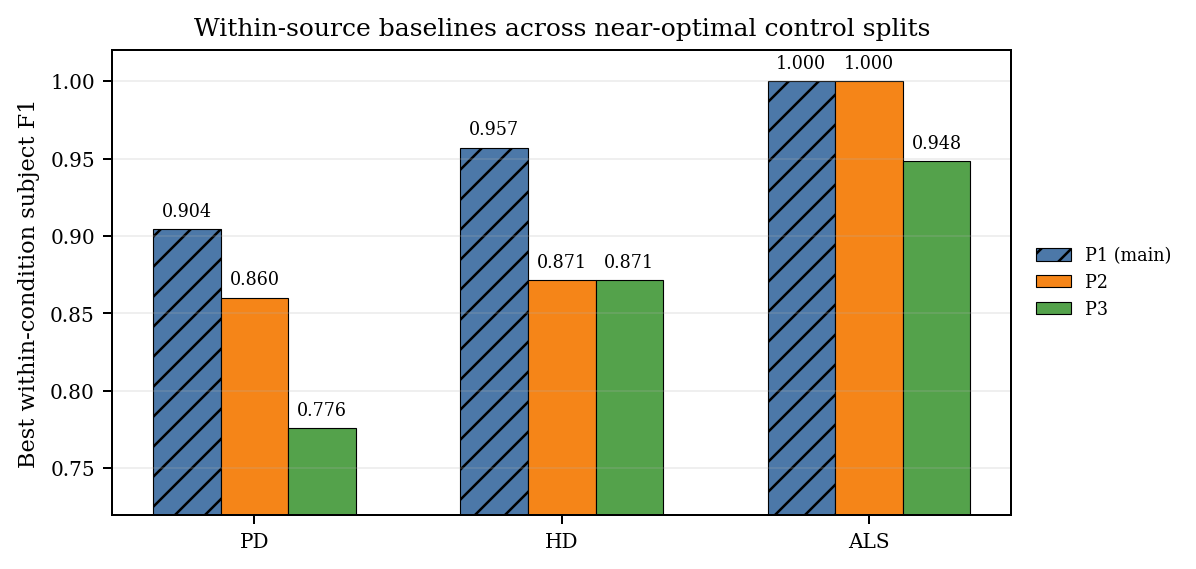

In [6]:

if step8_payload is not None:
    fig, ax = plt.subplots(figsize=(IEEE_TWO_COL * 0.90, 3.35))
    x = np.arange(len(COND_ORDER))
    width = 0.22
    offsets = [-width, 0.0, width]
    labels = ['P1 (main)', 'P2', 'P3']
    for offset, partition_index, label in zip(offsets, [1, 2, 3], labels):
        frame = within_df[within_df['partition_index'] == partition_index].set_index('condition').reindex(COND_ORDER)
        bars = ax.bar(
            x + offset,
            frame['best_subject_f1'].to_numpy(dtype=float),
            width=width,
            color=PARTITION_COLOR[partition_index],
            edgecolor='black',
            linewidth=0.45,
            label=label,
            hatch='//' if partition_index == 1 else None,
        )
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006, f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABEL[c] for c in COND_ORDER])
    ax.set_ylim(0.72, 1.02)
    ax.set_ylabel('Best within-condition subject F1')
    ax.set_title('Within-source baselines across near-optimal control splits')
    ax.grid(axis='y', alpha=0.2)
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    savefig_stem(fig, 'step8_within_source_baselines')
    plt.show()


## Best transfer leaders by direction and partition

The leader heatmap shows whether the best classifier family and best subject-level transfer score remain stable when the control partition changes. The figure is useful for nuance rather than a new headline: some directions keep broadly similar leader behavior, whereas others move enough that the manuscript should avoid wording that implies a universally stable transfer hierarchy.


Saved figure: report/figures/v4/pdf/step8/step8_best_transfer_leaders_heatmap.pdf
Saved figure: report/figures/v4/png/step8/step8_best_transfer_leaders_heatmap.png


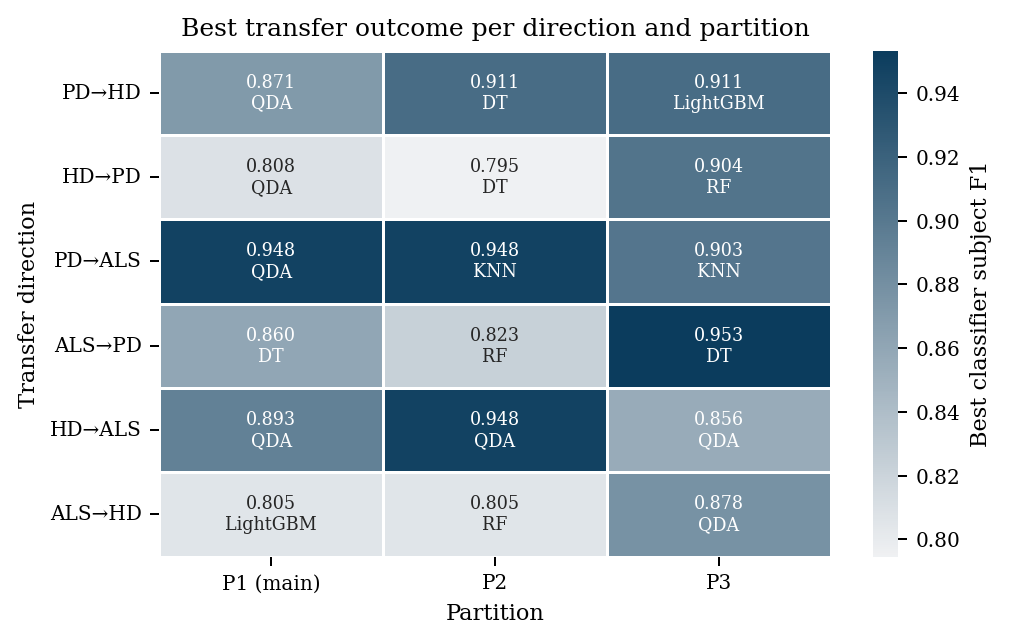

,Partition,Sign agreement rate,Ordering rank correlation
0,P1 (main),1.000,1.000
1,P2,1.000,0.543
2,P3,0.333,0.486


In [7]:

if step8_payload is not None:
    leader_heat = (
        leader_df.pivot(index='Direction', columns='Partition', values='Best subject F1')
        .reindex([DIR_LABEL[d] for d in DIRECTIONS])
    )
    leader_ann = (
        leader_df.assign(
            annotation=leader_df['Best subject F1'].map(lambda x: f'{x:.3f}') + '\n' + leader_df['Best classifier']
        )
        .pivot(index='Direction', columns='Partition', values='annotation')
        .reindex([DIR_LABEL[d] for d in DIRECTIONS])
    )
    fig, ax = plt.subplots(figsize=(IEEE_TWO_COL * 0.84, 3.65))
    sns.heatmap(
        leader_heat,
        cmap=sns.light_palette('#0B3C5D', as_cmap=True),
        annot=leader_ann,
        fmt='',
        annot_kws={'size': 7},
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Best classifier subject F1'},
        ax=ax,
    )
    ax.set_title('Best transfer outcome per direction and partition')
    ax.set_xlabel('Partition')
    ax.set_ylabel('Transfer direction')
    savefig_stem(fig, 'step8_best_transfer_leaders_heatmap')
    plt.show()

    same_sign_rows = partition_df[['Partition', 'Sign agreement rate', 'Ordering rank correlation']].copy()
    same_sign_rows['Sign agreement rate'] = same_sign_rows['Sign agreement rate'].map(lambda x: f'{x:.3f}')
    same_sign_rows['Ordering rank correlation'] = same_sign_rows['Ordering rank correlation'].map(lambda x: f'{x:.3f}')
    display(same_sign_rows)


## Interpretation cues

The safest final wording is that Step 8 **supports some main conclusions while qualifying others**. Partition 2 is broadly concordant with the main sign pattern, but partition 3 reverses four of six direction-level signs and therefore rules out any blanket invariance claim. The sign-stability matrix is the first high-level check, the direction-range figure is the second, and the within-source baseline panel explains why some of the movement arises even before the transferred models are considered.
